# Practical 3: Image Classification with a Convolutional Neural Network (CNN)

**Aim:** Build an image classification model divided into four stages.

**Dataset:** CIFAR-10, 60,000 colour images (32x32x3) in 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Read from `datasets/cifar10.npz`.

**Stages (as per syllabus):**
- a. Loading and preprocessing the image data
- b. Defining the model's architecture
- c. Training the model
- d. Estimating the model's performance

Why a CNN? A feedforward network flattens the image and loses which pixels are neighbours. A convolution layer slides small filters over the image, so it keeps the 2-D structure and reuses the same filter everywhere (far fewer weights).

In [2]:
# ---------------------------------------------------------------
# Common setup: imports, reproducibility, and offline data folder
# ---------------------------------------------------------------
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TensorFlow INFO/WARNING logs so outputs stay readable

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

# Fix the random seeds (Python, NumPy, TensorFlow) so every run gives similar numbers.
# This makes it easy to compare results between students.
keras.utils.set_random_seed(42)

# All data is read from the local "datasets" folder that sits next to this notebook.
# Nothing is downloaded from the internet.
DATA_DIR = Path("datasets")
MODEL_DIR = Path("models")
assert DATA_DIR.exists(), "datasets folder not found"



In [3]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

In [4]:
pwd

'/home/aditya/DVVP_DL_sep2026'

## Stage a: Loading and preprocessing the image data

In [5]:
data = np.load(DATA_DIR / "cifar10.npz")
x_train, y_train = data["x_train"], data["y_train"].reshape(-1)
x_test,  y_test  = data["x_test"],  data["y_test"].reshape(-1)

print("x_train:", x_train.shape, x_train.dtype, "| y_train:", y_train.shape)
print("x_test :", x_test.shape, "| y_test:", y_test.shape)

x_train: (50000, 32, 32, 3) uint8 | y_train: (50000,)
x_test : (10000, 32, 32, 3) | y_test: (10000,)


Image shape: (32, 32, 3) -> height, width, channels
Label: 6 = frog
Top-left pixel (R, G, B): [59 62 63]
Pixel range: 0 to 255


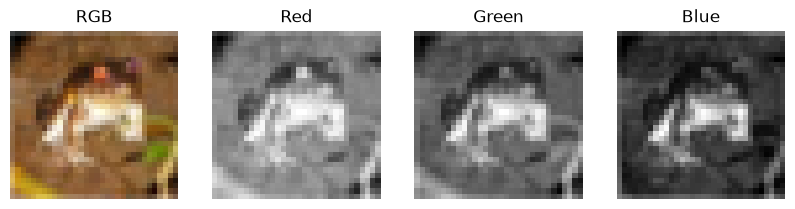

Image shape: (32, 32, 3) -> height, width, channels
Label: 9 = truck
Top-left pixel (R, G, B): [154 177 187]
Pixel range: 5 to 254


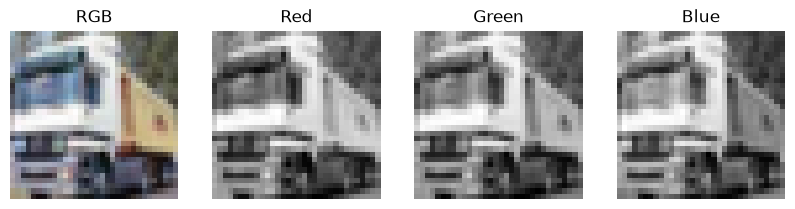

Image shape: (32, 32, 3) -> height, width, channels
Label: 9 = truck
Top-left pixel (R, G, B): [255 255 255]
Pixel range: 20 to 255


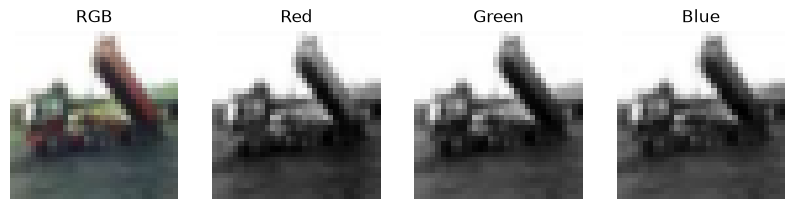

Image shape: (32, 32, 3) -> height, width, channels
Label: 4 = deer
Top-left pixel (R, G, B): [28 25 10]
Pixel range: 4 to 234


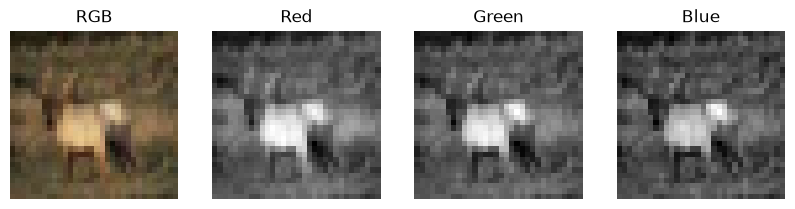

Image shape: (32, 32, 3) -> height, width, channels
Label: 1 = automobile
Top-left pixel (R, G, B): [170 180 198]
Pixel range: 0 to 254


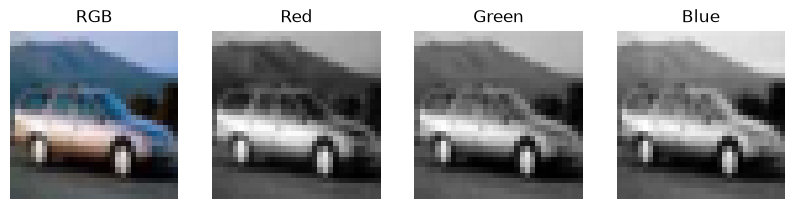

In [ ]:
# Inspect one/multiple image: it is a 32x32 grid, and every pixel has 3 numbers (Red, Green, Blue)
for i in range(5):
    img = x_train[i]
    print("Image shape:", img.shape, "-> height, width, channels")
    print("Label:", y_train[i], "=", CLASS_NAMES[y_train[i]])
    print("Top-left pixel (R, G, B):", img[0, 0])
    print("Pixel range:", img.min(), "to", img.max())

    # Show the image and its three colour channels separately
    fig, axes = plt.subplots(1, 4, figsize=(10, 3))
    axes[0].imshow(img); axes[0].set_title("RGB")
    for c, name in enumerate(["Red", "Green", "Blue"]):
        axes[c + 1].imshow(img[:, :, c], cmap="gray"); axes[c + 1].set_title(name)
    for a in axes: a.axis("off")
    plt.show()

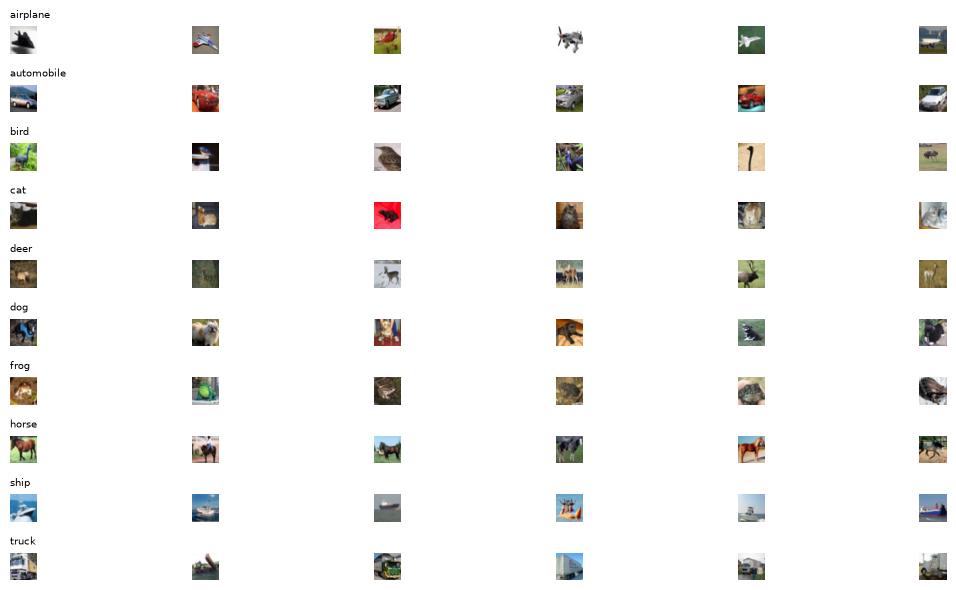

Images per class (train): [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


In [12]:
# A grid of sample images from each class
plt.figure(figsize=(12, 6))
for cls in range(10):
    idxs = np.where(y_train == cls)[0][:6]
    for j, idx in enumerate(idxs):
        plt.subplot(10, 6, cls * 6 + j + 1)
        plt.imshow(x_train[idx])
        plt.axis("off")
        if j == 0:
            plt.title(CLASS_NAMES[cls], fontsize=7, loc="left")
plt.tight_layout()
plt.show()

print("Images per class (train):", np.bincount(y_train))

### Preprocessing

1. Convert pixels to `float32` and scale to [0, 1] by dividing by 255.
2. Keep labels as integers (0-9). With integer labels we use `sparse_categorical_crossentropy`, which gives the same result as one-hot + `categorical_crossentropy` (used in Practical 2) without building the one-hot matrix.
3. Hold out 5,000 training images as a validation set to monitor overfitting.

In [13]:
x_train_f = x_train.astype("float32") / 255.0
x_test_f  = x_test.astype("float32") / 255.0

# The CIFAR-10 training data is already shuffled, so the last 5,000 images are a fair validation set
x_val_f, y_val = x_train_f[-5000:], y_train[-5000:]
x_tr_f,  y_tr  = x_train_f[:-5000], y_train[:-5000]

print("train:", x_tr_f.shape, "val:", x_val_f.shape, "test:", x_test_f.shape)
print("mean pixel value after scaling:", round(float(x_tr_f.mean()), 4))

train: (45000, 32, 32, 3) val: (5000, 32, 32, 3) test: (10000, 32, 32, 3)
mean pixel value after scaling: 0.4734


## Stage b: Defining the model's architecture

```
Input 32x32x3
 -> Conv2D(32, 3x3, ReLU) -> Conv2D(32, 3x3, ReLU) -> MaxPool 2x2      (edges, colours)
 -> Conv2D(64, 3x3, ReLU) -> Conv2D(64, 3x3, ReLU) -> MaxPool 2x2      (textures, parts)
 -> Flatten -> Dense(128, ReLU) -> Dropout(0.4) -> Dense(10, Softmax)   (classifier)
```

- `padding="same"` keeps the height and width unchanged after convolution.
- `MaxPooling2D(2)` halves height and width by keeping the maximum of every 2x2 block.
- `Dropout(0.4)` randomly switches off 40% of the neurons during training to reduce overfitting.

In [14]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1_1"),
    layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1_2"),
    layers.MaxPooling2D(2, name="pool1"),
    layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2_1"),
    layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2_2"),
    layers.MaxPooling2D(2, name="pool2"),
    layers.Flatten(name="flatten"),
    layers.Dense(128, activation="relu", name="dense"),
    layers.Dropout(0.4, name="dropout"),
    layers.Dense(10, activation="softmax", name="output"),
], name="cifar10_cnn")

model.summary()

2026-09-29 14:14:43.756979: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

### Inspect: how shapes and parameter counts are calculated

In [15]:
# Conv2D parameters = (kernel_h * kernel_w * input_channels + 1 bias) * number_of_filters
print("conv1_1:", (3*3*3 + 1) * 32, "params  (3x3 kernel over 3 input channels, 32 filters)")
print("conv1_2:", (3*3*32 + 1) * 32, "params")
print("conv2_1:", (3*3*32 + 1) * 64, "params")
print("conv2_2:", (3*3*64 + 1) * 64, "params")
print("dense  :", 8*8*64 * 128 + 128, "params  (flatten of 8x8x64 = 4096 inputs)")
print()

# Walk the layers and print the output shape after each one
x = keras.ops.zeros((1, 32, 32, 3))
for layer in model.layers:
    x = layer(x)
    print(f"{layer.name:>8} -> output shape {tuple(x.shape)}")

conv1_1: 896 params  (3x3 kernel over 3 input channels, 32 filters)
conv1_2: 9248 params
conv2_1: 18496 params
conv2_2: 36928 params
dense  : 524416 params  (flatten of 8x8x64 = 4096 inputs)

 conv1_1 -> output shape (1, 32, 32, 32)
 conv1_2 -> output shape (1, 32, 32, 32)
   pool1 -> output shape (1, 16, 16, 32)
 conv2_1 -> output shape (1, 16, 16, 64)
 conv2_2 -> output shape (1, 16, 16, 64)
   pool2 -> output shape (1, 8, 8, 64)
 flatten -> output shape (1, 4096)
   dense -> output shape (1, 128)
 dropout -> output shape (1, 128)
  output -> output shape (1, 10)


In [16]:
# The filters of the first conv layer: shape (3, 3, 3, 32) = 32 filters, each 3x3 over RGB.
W, b = model.get_layer("conv1_1").get_weights()
print("conv1_1 kernel shape:", W.shape, "| bias shape:", b.shape)
print("One filter (red channel slice) before training:\n", np.round(W[:, :, 0, 0], 3))

conv1_1 kernel shape: (3, 3, 3, 32) | bias shape: (32,)
One filter (red channel slice) before training:
 [[ 0.099  0.084 -0.017]
 [ 0.057  0.026 -0.132]
 [-0.032 -0.042  0.09 ]]


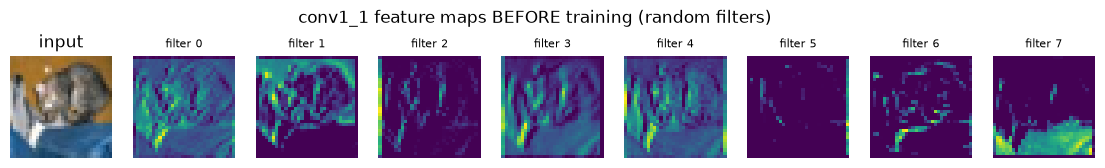

feature map shape: (32, 32, 32)


In [17]:
# Helper to visualise feature maps: what does a conv layer "see" for one image?
def show_feature_maps(model, layer_name, image, n=8, title=""):
    extractor = keras.Model(inputs=model.inputs, outputs=model.get_layer(layer_name).output)
    fmap = extractor.predict(image[np.newaxis], verbose=0)[0]     # shape (H, W, filters)
    plt.figure(figsize=(14, 2))
    plt.subplot(1, n + 1, 1); plt.imshow(image); plt.title("input"); plt.axis("off")
    for i in range(n):
        plt.subplot(1, n + 1, i + 2)
        plt.imshow(fmap[:, :, i], cmap="viridis")
        plt.title(f"filter {i}", fontsize=8); plt.axis("off")
    plt.suptitle(title); plt.show()
    return fmap.shape

print("feature map shape:", show_feature_maps(model, "conv1_1", x_test_f[0],
                                             title="conv1_1 feature maps BEFORE training (random filters)"))

## Stage c: Training the model

- **Optimizer:** Adam (adapts the learning rate for every weight; converges faster than plain SGD for CNNs).
- **Loss:** `sparse_categorical_crossentropy` (integer labels).
- **EarlyStopping:** stops training if validation loss does not improve for 3 epochs and restores the best weights. This saves time and prevents overfitting.

On a normal lab CPU one epoch takes roughly 30-90 seconds. Reduce `EPOCHS` if time is short.

In [18]:
EPOCHS = 12
BATCH_SIZE = 64

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(x_tr_f, y_tr,
                    validation_data=(x_val_f, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[early_stop], verbose=1)

print("Epochs actually run:", len(history.history["loss"]))

Epoch 1/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.4147 - loss: 1.5929 - val_accuracy: 0.5814 - val_loss: 1.1754
Epoch 2/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5873 - loss: 1.1650 - val_accuracy: 0.6822 - val_loss: 0.9361
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.6521 - loss: 0.9888 - val_accuracy: 0.7134 - val_loss: 0.8422
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.6934 - loss: 0.8763 - val_accuracy: 0.7110 - val_loss: 0.8381
Epoch 5/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.7234 - loss: 0.7919 - val_accuracy: 0.7378 - val_loss: 0.7578
Epoch 6/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7471 - loss: 0.7159 - val_accuracy: 0.7312 - val_loss: 0.7794
Epoch 7/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.7645 - loss: 0.6695 - val_accuracy: 0.7484 - val_loss: 0.7679
Epoch 8/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.7781 - loss: 0.6181 - 

Filter 0 (red slice) after training:
 [[ 0.117  0.122 -0.015]
 [ 0.116  0.065 -0.18 ]
 [-0.04  -0.091  0.088]]
Mean absolute change in conv1_1 weights: 0.038660358637571335


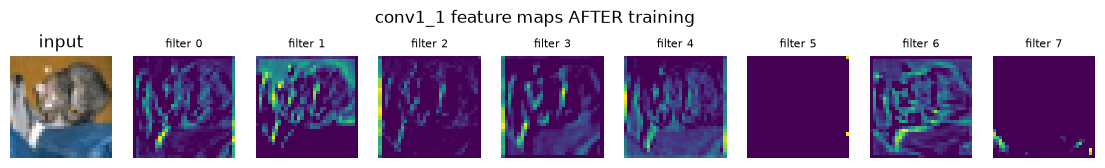

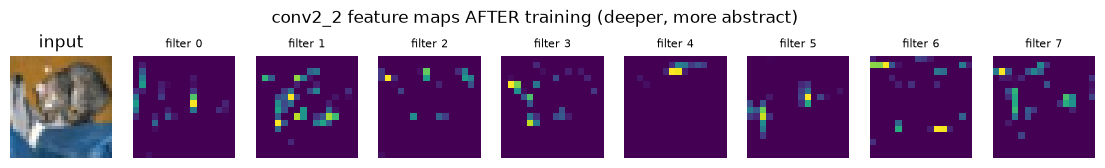

In [19]:
# Same filter as before, after training: it now has structure instead of random noise
W_after, _ = model.get_layer("conv1_1").get_weights()
print("Filter 0 (red slice) after training:\n", np.round(W_after[:, :, 0, 0], 3))
print("Mean absolute change in conv1_1 weights:", float(np.abs(W_after - W).mean()))

show_feature_maps(model, "conv1_1", x_test_f[0], title="conv1_1 feature maps AFTER training")
show_feature_maps(model, "conv2_2", x_test_f[0], title="conv2_2 feature maps AFTER training (deeper, more abstract)");

## Stage d: Estimating the model's performance

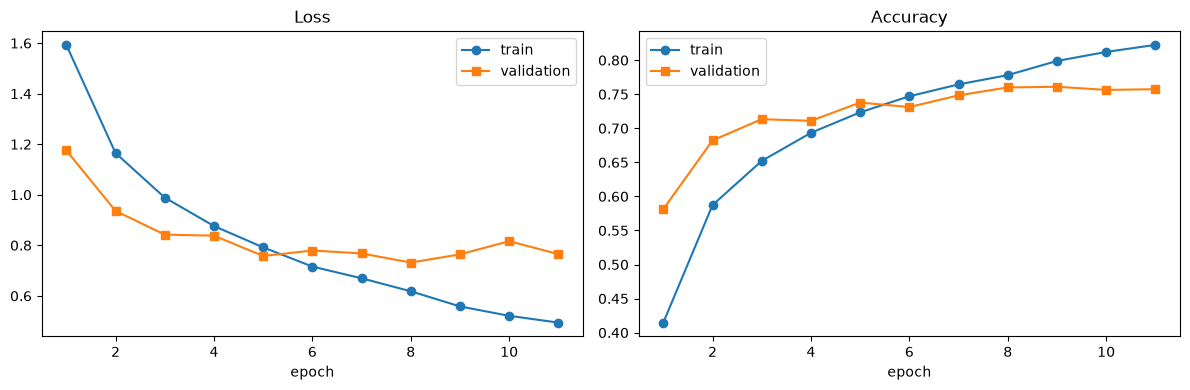

In [20]:
h = history.history
ep = range(1, len(h["loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ep, h["loss"], "o-", label="train"); plt.plot(ep, h["val_loss"], "s-", label="validation")
plt.title("Loss"); plt.xlabel("epoch"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(ep, h["accuracy"], "o-", label="train"); plt.plot(ep, h["val_accuracy"], "s-", label="validation")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()
plt.tight_layout(); plt.show()

Test loss: 0.7632 | Test accuracy: 0.7439


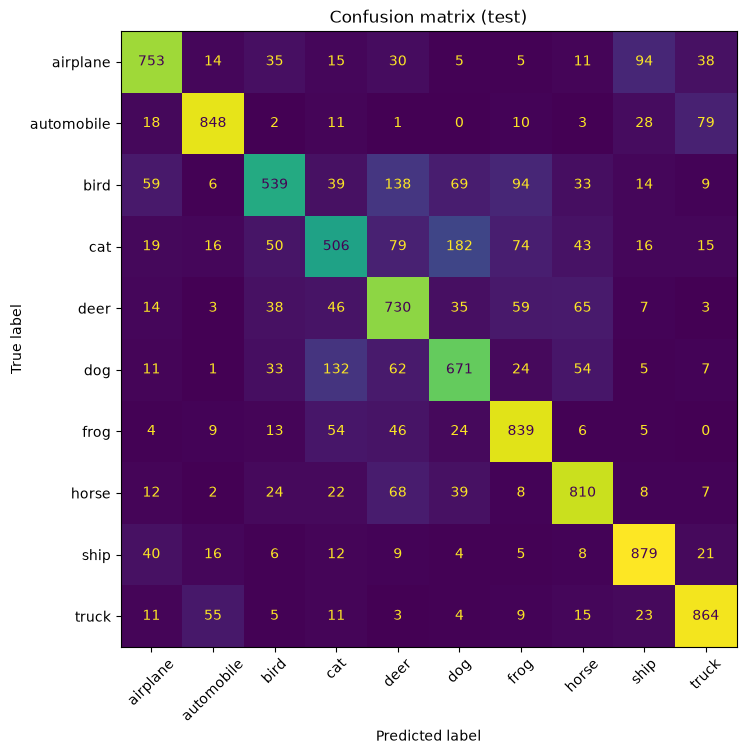

              precision    recall  f1-score   support

    airplane      0.800     0.753     0.776      1000
  automobile      0.874     0.848     0.861      1000
        bird      0.723     0.539     0.618      1000
         cat      0.597     0.506     0.548      1000
        deer      0.626     0.730     0.674      1000
         dog      0.650     0.671     0.660      1000
        frog      0.744     0.839     0.789      1000
       horse      0.773     0.810     0.791      1000
        ship      0.815     0.879     0.846      1000
       truck      0.828     0.864     0.846      1000

    accuracy                          0.744     10000
   macro avg      0.743     0.744     0.741     10000
weighted avg      0.743     0.744     0.741     10000



In [21]:
test_loss, test_acc = model.evaluate(x_test_f, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

probs = model.predict(x_test_f, verbose=0)
y_pred = probs.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, xticks_rotation=45)
plt.title("Confusion matrix (test)"); plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

In [22]:
# Per-class accuracy: which classes are hard? (cat vs dog is usually the hardest pair)
per_class = cm.diagonal() / cm.sum(axis=1)
for name, acc in sorted(zip(CLASS_NAMES, per_class), key=lambda t: t[1]):
    print(f"{name:>10}: {acc:.3f}")

# The most confused pair of different classes
off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"\nMost common mistake: true '{CLASS_NAMES[i]}' predicted as '{CLASS_NAMES[j]}' ({off[i, j]} times)")

       cat: 0.506
      bird: 0.539
       dog: 0.671
      deer: 0.730
  airplane: 0.753
     horse: 0.810
      frog: 0.839
automobile: 0.848
     truck: 0.864
      ship: 0.879

Most common mistake: true 'cat' predicted as 'dog' (182 times)


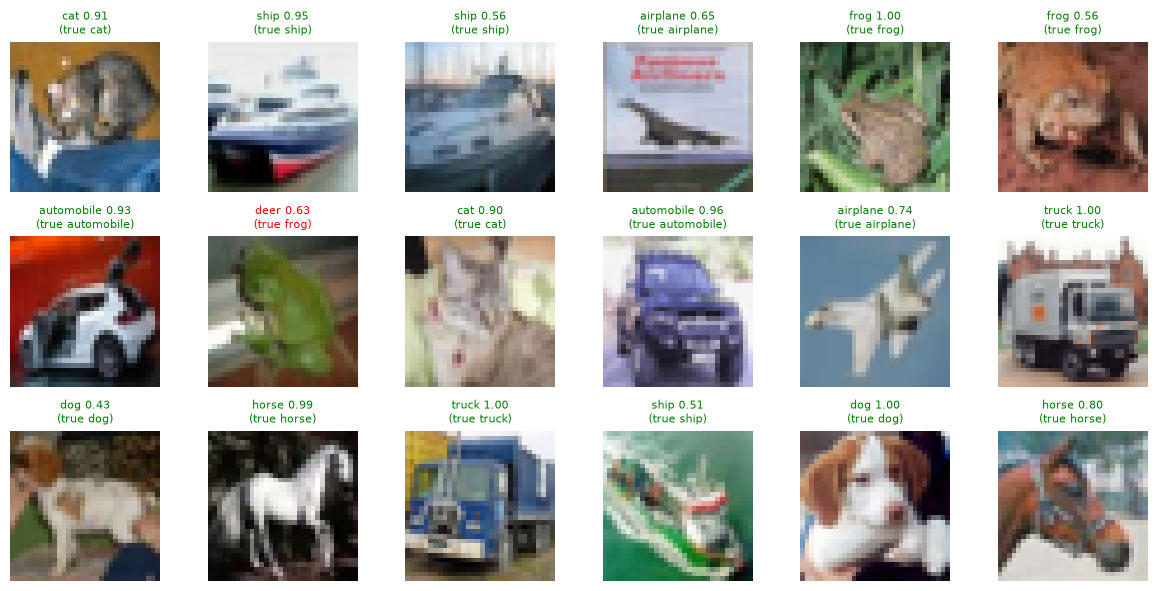

In [23]:
# Show test images with the top prediction and its confidence (green = correct, red = wrong)
plt.figure(figsize=(12, 6))
for k in range(18):
    plt.subplot(3, 6, k + 1)
    plt.imshow(x_test[k])
    correct = y_pred[k] == y_test[k]
    plt.title(f"{CLASS_NAMES[y_pred[k]]} {probs[k].max():.2f}\n(true {CLASS_NAMES[y_test[k]]})",
              fontsize=8, color="green" if correct else "red")
    plt.axis("off")
plt.tight_layout(); plt.show()

In [24]:
# Save the trained model and load it back to confirm it predicts the same thing.
# (A saved .keras file can be reused later without retraining.)
model.save("p3_cifar10_cnn.keras")
reloaded = keras.models.load_model("p3_cifar10_cnn.keras")
same = np.allclose(reloaded.predict(x_test_f[:5], verbose=0), probs[:5], atol=1e-5)
print("Reloaded model gives identical predictions:", same)

Reloaded model gives identical predictions: True


## Try it yourself (optional)

1. Remove the `Dropout` layer and retrain. Compare the gap between training and validation accuracy.
2. Add a third block `Conv2D(128) -> Conv2D(128) -> MaxPool` before `Flatten`.
3. Add data augmentation at the start of the model: `layers.RandomFlip("horizontal")`, `layers.RandomTranslation(0.1, 0.1)`.

## Conclusion

We built a CNN in four clear stages. It reaches about 70-75% test accuracy on CIFAR-10 in around 10 epochs on a CPU, far better than the feedforward network of Practical 2 on the same data, because convolutions keep the spatial structure of the image.